# RQVAE: Residual Quantized VAE for Semantic ID Generation

**Part 2a of the Sequential Recommenders series**

This notebook implements:

1. **Data Loading** — Steam Games dataset with 5-core filtering
2. **Embedding** — Qwen3-Embedding-4B with MRL truncation to 1024D
3. **RQVAE Training** — Residual Quantized VAE to convert embeddings into discrete tokens
4. **Semantic ID Assignment** — 3 RQVAE levels + 1 collision-resolution level = 4 tokens per item

**Output:** Checkpoints 1-2 consumed by the SASRec, Semantic SASRec, and TIGER notebooks.


---
## 1. Setup

In [1]:
import os
import gc
import ast
import gzip
import json
import time
import pickle
import subprocess
from collections import defaultdict, Counter
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict, NamedTuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm

os.environ["TOKENIZERS_PARALLELISM"] = "false"

%matplotlib inline
sns.set_style('whitegrid')

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
if device == 'cuda':
    torch.set_float32_matmul_precision('high')
    print(f"GPU: {torch.cuda.get_device_name()}")

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cuda
GPU: NVIDIA A10G


---
## 2. Load Steam Game Data

We join two datasets:
- **UCSD Steam Interactions** — same user-item interactions from Part 1, with 5-core filtering
- **FronKonGames Steam Metadata** — rich game descriptions, genres, tags for embedding

The result: the exact same ~5,000 games used in Part 1's SASRec, now with rich text descriptions.

In [3]:
def download_interaction_data():
    """Download UCSD Steam interaction data (same as Part 1 SASRec notebook)."""
    if os.path.exists('steam_reviews.json.gz'):
        print('steam_reviews.json.gz already exists')
        return True
    
    url = 'https://mcauleylab.ucsd.edu/public_datasets/data/steam/australian_users_items.json.gz'
    print(f'Downloading from {url}...')
    response = requests.get(url, stream=True, timeout=30)
    response.raise_for_status()
    
    total = int(response.headers.get('content-length', 0))
    with open('steam_reviews.json.gz', 'wb') as f:
        pbar = tqdm(total=total, unit='B', unit_scale=True)
        for chunk in response.iter_content(8192):
            f.write(chunk)
            pbar.update(len(chunk))
        pbar.close()
    return True


def download_metadata():
    """Download FronKonGames Steam metadata from Kaggle."""
    if os.path.exists('games.json'):
        print('games.json already exists')
        return True
    
    print('Downloading from Kaggle (fronkongames/steam-games-dataset)...')
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', 'fronkongames/steam-games-dataset', '-p', '.', '--unzip'],
        capture_output=True, text=True, timeout=300
    )
    if result.returncode == 0:
        print('Download complete')
        return True
    else:
        print(f'Download failed: {result.stderr}')
        print('Manual: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset')
        return False


def load_interactions_5core(k=5):
    """Load UCSD interactions and apply 5-core filtering (identical to Part 1)."""
    download_interaction_data()
    
    print('Loading user interactions...')
    user_sequences = defaultdict(list)
    
    with gzip.open('steam_reviews.json.gz', 'rt', encoding='utf-8') as f:
        for line in tqdm(f, desc='Reading reviews'):
            try:
                data = ast.literal_eval(line.strip())
                user_id = data.get('user_id') or data.get('steamid')
                if not user_id or 'items' not in data:
                    continue
                for item in data['items']:
                    item_id = item.get('item_id') or item.get('app_id')
                    playtime = item.get('playtime_forever', 0) or item.get('playtime', 0)
                    if item_id and playtime / 60.0 > 1.0:
                        user_sequences[user_id].append({'item_id': str(item_id), 'hours': playtime / 60.0})
            except:
                continue
    
    print(f'Raw: {len(user_sequences):,} users')
    
    # Iterative 5-core filtering
    prev = len(user_sequences)
    for iteration in range(50):
        user_sequences = {u: s for u, s in user_sequences.items() if len(s) >= k}
        item_counts = defaultdict(int)
        for seq in user_sequences.values():
            for item in seq:
                item_counts[item['item_id']] += 1
        user_sequences = {
            u: [i for i in s if item_counts[i['item_id']] >= k]
            for u, s in user_sequences.items()
        }
        user_sequences = {u: s for u, s in user_sequences.items() if len(s) >= k}
        if len(user_sequences) == prev:
            break
        prev = len(user_sequences)
    
    game_ids = sorted(set(item['item_id'] for seq in user_sequences.values() for item in seq))
    print(f'After {k}-core: {len(user_sequences):,} users, {len(game_ids):,} games')
    return user_sequences, set(game_ids)


def load_games_with_metadata(sasrec_game_ids):
    """Load rich game metadata filtered to SASRec game set."""
    download_metadata()
    
    with open('games.json', 'r', encoding='utf-8') as f:
        all_games = json.load(f)
    if 'root' in all_games:
        all_games = all_games['root']
    
    games = []
    for app_id, game in all_games.items():
        if str(app_id) not in sasrec_game_ids:
            continue
        
        name = game.get('name', '')
        short_desc = game.get('short_description', '')
        detailed_desc = game.get('detailed_description', '')
        genres = ', '.join(game.get('genres', [])[:5]) if isinstance(game.get('genres'), list) else ''
        
        tags_dict = game.get('tags', {})
        if isinstance(tags_dict, dict):
            tags = ', '.join(t for t, _ in sorted(tags_dict.items(), key=lambda x: x[1], reverse=True)[:10])
        else:
            tags = ''
        
        categories = ', '.join(game.get('categories', [])[:5]) if isinstance(game.get('categories'), list) else ''
        
        parts = []
        if name: parts.append(f'Game: {name}')
        if genres: parts.append(f'Genres: {genres}')
        if tags: parts.append(f'Tags: {tags}')
        if categories: parts.append(f'Categories: {categories}')
        if short_desc: parts.append(f'Summary: {short_desc}')
        if detailed_desc: parts.append(f'Description: {detailed_desc}')
        
        text = '. '.join(parts)
        if detailed_desc or short_desc or genres or tags:
            games.append({'app_id': str(app_id), 'name': name, 'genres': genres,
                          'tags': tags, 'short_description': short_desc, 'text': text})
    
    df = pd.DataFrame(games)
    print(f'Matched {len(df):,} / {len(sasrec_game_ids):,} games with metadata')
    print(f'Avg text length: {df["text"].str.len().mean():.0f} chars')
    return df

In [4]:
# Load everything
user_sequences, sasrec_game_ids = load_interactions_5core()
games_df = load_games_with_metadata(sasrec_game_ids)
print(f'\nDataset: {len(games_df):,} games with metadata')

steam_reviews.json.gz already exists
Loading user interactions...


Reading reviews: 0it [00:00, ?it/s]

Raw: 67,287 users
After 5-core: 56,808 users, 6,382 games
games.json already exists
Matched 5,232 / 6,382 games with metadata
Avg text length: 2057 chars

Dataset: 5,232 games with metadata


---
## 3. Embedding with Qwen3-Embedding-4B

We use **Qwen3-Embedding-4B** to encode game descriptions into dense vectors.

Qwen3 is instruction-aware: we prepend a task instruction that tells the model what kind of embedding to generate. It uses **last-token pooling** (not CLS) — the final token's hidden state is the embedding.

### Matryoshka Representation Learning (MRL)

Qwen3-Embedding-4B produces 2560-dimensional vectors, but we truncate to **1024 dimensions**. This works because Qwen3 is trained with **Matryoshka Representation Learning** — the model is trained so that any prefix of the full embedding is itself a valid, high-quality embedding. Like a Russian nesting doll where each inner doll is still a complete figure.

1024 dimensions gives us a good balance: rich enough for the RQVAE to learn meaningful codes, compact enough to train efficiently.

In [13]:
from transformers import AutoModel, AutoTokenizer

MODEL_NAME = 'Qwen/Qwen3-Embedding-4B'
TARGET_DIM = 1024  # MRL truncation: 2560 -> 1024


def last_token_pool(last_hidden_states: Tensor, attention_mask: Tensor) -> Tensor:
    """Extract embeddings using last-token pooling (Qwen3's approach)."""
    left_padding = attention_mask[:, -1].sum() == attention_mask.shape[0]
    if left_padding:
        return last_hidden_states[:, -1]
    sequence_lengths = attention_mask.sum(dim=1) - 1
    batch_size = last_hidden_states.shape[0]
    return last_hidden_states[
        torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths
    ]


def embed_items(texts, model, tokenizer, batch_size=4, target_dim=TARGET_DIM):
    """Generate embeddings with instruction-tuned prompting and MRL truncation."""
    task = ('Given a product description, generate a semantic embedding '
            'that captures its key features and characteristics')
    instructed = [f'Instruct: {task}\nQuery: {t}' for t in texts]
    
    all_embeddings = []
    for i in tqdm(range(0, len(instructed), batch_size), desc='Embedding'):
        batch = instructed[i:i + batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                           max_length=2048, return_tensors='pt').to(device)
        
        with torch.no_grad():
            outputs = model(**encoded)
            embs = last_token_pool(outputs.last_hidden_state, encoded['attention_mask'])
            # MRL truncation
            if target_dim and target_dim < embs.shape[1]:
                embs = embs[:, :target_dim]
            embs = F.normalize(embs, p=2, dim=1)
            all_embeddings.append(embs.cpu())
        
        if device == 'cuda':
            torch.cuda.empty_cache()
    
    return torch.cat(all_embeddings, dim=0)


# Load model
print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, dtype=torch.float16).to(device).eval()
print(f'Model hidden size: {model.config.hidden_size}, Target dim: {TARGET_DIM}')

# Generate embeddings
item_embeddings = embed_items(games_df['text'].tolist(), model, tokenizer)
print(f'Embeddings shape: {item_embeddings.shape}')
print(f'L2 norms — Mean: {item_embeddings.norm(dim=1).mean():.4f}, Std: {item_embeddings.norm(dim=1).std():.6f}')

# Free GPU memory
del model
gc.collect()
if device == 'cuda':
    torch.cuda.empty_cache()

Loading Qwen/Qwen3-Embedding-4B...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model hidden size: 2560, Target dim: 1024


Embedding:   0%|          | 0/1308 [00:00<?, ?it/s]

Embeddings shape: torch.Size([5232, 1024])
L2 norms — Mean: 1.0000, Std: 0.000177


In [14]:
# ============================================================
# Checkpoint 1: Save embeddings and data (after cell above)
# ============================================================
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

torch.save(item_embeddings, f'{CHECKPOINT_DIR}/item_embeddings.pt')
with open(f'{CHECKPOINT_DIR}/data_checkpoint1.pkl', 'wb') as f:
    pickle.dump({
        'games_df': games_df,
        'user_sequences': dict(user_sequences),
        'sasrec_game_ids': sasrec_game_ids,
    }, f)
print(f'Checkpoint 1 saved: item_embeddings {item_embeddings.shape}, '
      f'{len(games_df)} games, {len(user_sequences)} users')

Checkpoint 1 saved: item_embeddings torch.Size([5232, 1024]), 5232 games, 56808 users


In [15]:
# ============================================================
# Load Checkpoint 1 (run this instead of cells 2-6 to resume)
# ============================================================
CHECKPOINT_DIR = 'checkpoints'

item_embeddings = torch.load(f'{CHECKPOINT_DIR}/item_embeddings.pt', weights_only=True)
with open(f'{CHECKPOINT_DIR}/data_checkpoint1.pkl', 'rb') as f:
    _ckpt = pickle.load(f)
    games_df = _ckpt['games_df']
    user_sequences = _ckpt['user_sequences']
    sasrec_game_ids = _ckpt['sasrec_game_ids']
    del _ckpt

print(f'Checkpoint 1 loaded: item_embeddings {item_embeddings.shape}, '
      f'{len(games_df)} games, {len(user_sequences)} users')

Checkpoint 1 loaded: item_embeddings torch.Size([5232, 1024]), 5232 games, 56808 users


---
## 4. RQVAE — Residual Quantized Variational Autoencoder

The RQVAE converts each 1024-dim embedding into a sequence of 3 discrete tokens.

**Architecture:**
- **Encoder:** 1024 → 512 → 256 → 128 → 32 (SiLU activations)
- **3 Vector Quantizers:** each with 256 codes of dimension 32
- **Decoder:** 32 → 128 → 256 → 512 → 1024 (mirror of encoder)

**Key ideas:**
- Each VQ level quantizes the *residual* from the previous level
- **Rotation trick** (Fifty et al. 2025) for gradient flow through quantization
- **K-means initialization** + **periodic codebook reset** to prevent collapse

In [17]:
# ============================================================
# RQVAE Implementation
# ============================================================

class QuantizationOutput(NamedTuple):
    quantized_st: Tensor   # Quantized with gradient estimator applied
    quantized: Tensor      # Quantized (detached)
    indices: Tensor        # Codebook indices
    loss: Tensor           # Total VQ loss
    codebook_loss: Tensor  # Loss moving codebook toward encoder
    commitment_loss: Tensor  # Loss moving encoder toward codebook


class VectorQuantizer(nn.Module):
    """Vector quantization layer with rotation trick for gradient flow."""
    
    def __init__(self, codebook_size=256, codebook_dim=32, commitment_weight=0.25):
        super().__init__()
        self.codebook_size = codebook_size
        self.codebook_dim = codebook_dim
        self.commitment_weight = commitment_weight
        
        self.embedding = nn.Embedding(codebook_size, codebook_dim)
        self.embedding.weight.data.uniform_(-1 / codebook_size, 1 / codebook_size)
        
        self.register_buffer('usage_count', torch.zeros(codebook_size))
        self.register_buffer('update_count', torch.tensor(0))
    
    @staticmethod
    def rotate_to(src: Tensor, tgt: Tensor) -> Tensor:
        """Rotation trick (Fifty et al. 2025) — smooth gradient through VQ.
        
        Forward: returns tgt exactly.
        Backward: gradients flow through a rotation from src to tgt.
        """
        src_flat = src.reshape(-1, src.shape[-1])
        tgt_flat = tgt.reshape(-1, tgt.shape[-1])
        
        norm_src = src_flat.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        norm_tgt = tgt_flat.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        
        u = src_flat / norm_src
        q = tgt_flat / norm_tgt
        w = F.normalize(u + q, dim=-1).detach()
        
        # Householder-like rotation
        w_col, w_row = w.unsqueeze(-1), w.unsqueeze(-2)
        u_col = u.unsqueeze(-1).detach()
        q_row = q.unsqueeze(-2).detach()
        
        e = src_flat.unsqueeze(1)
        rotated = e - 2 * (e @ w_col @ w_row) + 2 * (e @ u_col @ q_row)
        rotated = rotated.squeeze(1)
        
        # Scale to match target norm
        rotated = rotated * (norm_tgt / norm_src).detach()
        return rotated.reshape(src.shape)
    
    def find_nearest_codes(self, x):
        distances = torch.cdist(x.reshape(-1, self.codebook_dim), self.embedding.weight)
        indices = distances.argmin(dim=1)
        quantized = self.embedding(indices).view(x.shape)
        return indices.view(x.shape[:-1]), quantized
    
    def forward(self, x):
        indices, quantized = self.find_nearest_codes(x)
        
        # Gradient estimator
        if self.training and x.requires_grad:
            quantized_st = self.rotate_to(x, quantized)
        else:
            quantized_st = quantized
        
        # VQ losses
        codebook_loss = F.mse_loss(x.detach(), quantized)
        commitment_loss = F.mse_loss(x, quantized.detach())
        loss = codebook_loss + self.commitment_weight * commitment_loss
        
        if self.training:
            self.usage_count.scatter_add_(0, indices.flatten(),
                                          torch.ones_like(indices.flatten(), dtype=torch.float))
            self.update_count += 1
        
        return QuantizationOutput(quantized_st, quantized, indices, loss, codebook_loss, commitment_loss)
    
    def reset_unused_codes(self, batch_data):
        """Replace dead codebook entries with random vectors from the batch."""
        if self.update_count == 0:
            return
        unused = (self.usage_count == 0).nonzero().squeeze(-1)
        if len(unused) > 0 and batch_data.shape[0] >= len(unused):
            flat = batch_data.reshape(-1, self.codebook_dim)
            rand_idx = torch.randperm(flat.shape[0], device=flat.device)[:len(unused)]
            self.embedding.weight.data[unused] = flat[rand_idx].detach()
        self.usage_count.zero_()
    
    def get_usage_rate(self):
        if self.update_count == 0:
            return 0.0
        return (self.usage_count > 0).float().mean().item()


class RQVAE(nn.Module):
    """Residual Quantized VAE for generating Semantic IDs."""
    
    def __init__(self, input_dim=1024, hidden_dims=(512, 256, 128),
                 codebook_dim=32, num_levels=3, codebook_size=256,
                 commitment_weight=0.25):
        super().__init__()
        self.codebook_dim = codebook_dim
        self.num_levels = num_levels
        self.codebook_size = codebook_size
        
        # Encoder: input_dim -> hidden_dims -> codebook_dim
        dims = [input_dim] + list(hidden_dims) + [codebook_dim]
        enc_layers = []
        for i in range(len(dims) - 2):
            enc_layers.extend([nn.Linear(dims[i], dims[i+1]), nn.SiLU()])
        enc_layers.append(nn.Linear(dims[-2], dims[-1]))
        self.encoder = nn.Sequential(*enc_layers)
        
        # Decoder: mirror of encoder
        dims_rev = [codebook_dim] + list(reversed(hidden_dims)) + [input_dim]
        dec_layers = []
        for i in range(len(dims_rev) - 2):
            dec_layers.extend([nn.Linear(dims_rev[i], dims_rev[i+1]), nn.SiLU()])
        dec_layers.append(nn.Linear(dims_rev[-2], dims_rev[-1]))
        self.decoder = nn.Sequential(*dec_layers)
        
        # Quantization layers
        self.vq_layers = nn.ModuleList([
            VectorQuantizer(codebook_size, codebook_dim, commitment_weight)
            for _ in range(num_levels)
        ])
    
    def forward(self, x):
        z = self.encoder(x)
        
        quantized_out = torch.zeros_like(z)
        residual = z
        all_indices = []
        vq_loss = 0
        codebook_losses, commitment_losses = [], []
        
        for vq in self.vq_layers:
            out = vq(residual)
            residual = residual - out.quantized.detach()
            quantized_out = quantized_out + out.quantized_st
            all_indices.append(out.indices)
            vq_loss = vq_loss + out.loss
            codebook_losses.append(out.codebook_loss)
            commitment_losses.append(out.commitment_loss)
        
        x_recon = self.decoder(quantized_out)
        recon_loss = F.mse_loss(x_recon, x)
        
        return x_recon, all_indices, {
            'loss': recon_loss + vq_loss, 'recon_loss': recon_loss, 'vq_loss': vq_loss,
            'codebook_losses': codebook_losses, 'commitment_losses': commitment_losses,
            'indices': all_indices, 'residual': residual
        }
    
    @torch.no_grad()
    def encode_to_semantic_ids(self, x):
        """Extract [B, num_levels] semantic ID tensor."""
        z = self.encoder(x)
        residual = z
        ids = []
        for vq in self.vq_layers:
            out = vq(residual)
            ids.append(out.indices)
            residual = residual - out.quantized
        return torch.stack(ids, dim=-1)
    
    def kmeans_init(self, data_loader, device):
        """Initialize codebooks with k-means on encoded data."""
        print('K-means codebook initialization...')
        batch = next(iter(data_loader)).to(device)
        with torch.no_grad():
            z = self.encoder(batch)
            residual = z
            for level, vq in enumerate(self.vq_layers):
                data_np = residual.cpu().numpy().reshape(-1, self.codebook_dim)
                km = KMeans(n_clusters=self.codebook_size, n_init=10, random_state=0)
                km.fit(data_np)
                vq.embedding.weight.data = torch.from_numpy(km.cluster_centers_).to(device)
                print(f'  Level {level}: initialized {self.codebook_size} codes')
                if level < self.num_levels - 1:
                    out = vq(residual)
                    residual = residual - out.quantized


print('RQVAE classes defined')

RQVAE classes defined


### 4a. Train the RQVAE

In [18]:
# Training configuration
RQVAE_CONFIG = {
    'input_dim': TARGET_DIM,          # 1024 (from Qwen3 with MRL)
    'hidden_dims': (512, 256, 128),
    'codebook_dim': 32,
    'num_levels': 3,
    'codebook_size': 256,
    'commitment_weight': 0.25,
}

BATCH_SIZE = min(4096, len(item_embeddings))  # Fit full dataset if small enough
NUM_EPOCHS = 5000
MAX_LR = 3e-4
MIN_LR = 1e-6
WARMUP_STEPS = 200
CODEBOOK_RESET_EVERY = 2

# Dataset
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings):
        self.embeddings = embeddings
    def __len__(self): return len(self.embeddings)
    def __getitem__(self, idx): return self.embeddings[idx]

dataset = EmbeddingDataset(item_embeddings.float())

# Split
val_size = int(len(dataset) * 0.05)
train_size = len(dataset) - val_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size],
                                                  generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=(device=='cuda'), drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=(device=='cuda'))

print(f'Train: {train_size:,}, Val: {val_size:,}')
print(f'Batch size: {BATCH_SIZE}, Steps/epoch: {len(train_loader)}')
print(f'Total steps: {len(train_loader) * NUM_EPOCHS:,}')

Train: 4,971, Val: 261
Batch size: 4096, Steps/epoch: 2
Total steps: 10,000


In [19]:
# Build model
rqvae = RQVAE(**RQVAE_CONFIG).to(device)

In [ ]:
total_params = sum(p.numel() for p in rqvae.parameters())
print(f'RQVAE parameters: {total_params:,}')

# K-means init
rqvae.kmeans_init(train_loader, device)

# Optimizer + scheduler
optimizer = torch.optim.AdamW(rqvae.parameters(), lr=MAX_LR, weight_decay=0.01)
total_steps = len(train_loader) * NUM_EPOCHS

warmup_sched = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1e-8/MAX_LR, total_iters=WARMUP_STEPS)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps - WARMUP_STEPS, eta_min=MIN_LR)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, [warmup_sched, cosine_sched], milestones=[WARMUP_STEPS])

# Training loop
best_val_loss = float('inf')
global_step = 0
history = {'step': [], 'loss': [], 'recon': [], 'vq': [], 'usage': [], 'unique': []}

print(f'\nTraining RQVAE for {NUM_EPOCHS} epochs...')
print(f'Encoder: {TARGET_DIM} -> 512 -> 256 -> 128 -> 32')
print(f'Codebooks: {RQVAE_CONFIG["num_levels"]} levels x {RQVAE_CONFIG["codebook_size"]} codes')

for epoch in range(NUM_EPOCHS):
    rqvae.train()
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        _, indices, loss_dict = rqvae(batch)
        loss_dict['loss'].backward()
        
        torch.nn.utils.clip_grad_norm_(rqvae.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        global_step += 1
        
        # Codebook reset
        if global_step % CODEBOOK_RESET_EVERY == 0 and global_step > WARMUP_STEPS:
            rqvae.eval()
            with torch.no_grad():
                reset_batch = next(iter(train_loader)).to(device)
                z = rqvae.encoder(reset_batch)
                residual = z
                for vq in rqvae.vq_layers:
                    if vq.get_usage_rate() < 1.0:
                        vq.reset_unused_codes(residual)
                    out = vq(residual)
                    residual = residual - out.quantized
                    vq.usage_count.zero_()
            rqvae.train()
    
    # Log every 100 epochs
    if (epoch + 1) % 100 == 0 or epoch == 0:
        rqvae.eval()
        # Validation
        val_losses = []
        with torch.no_grad():
            for vb in val_loader:
                _, _, vl = rqvae(vb.to(device))
                val_losses.append(vl['loss'].item())
        val_loss = np.mean(val_losses)
        
        # Codebook stats
        usage = [vq.get_usage_rate() for vq in rqvae.vq_layers]
        
        # Unique IDs
        with torch.no_grad():
            sample = next(iter(train_loader)).to(device)
            sids = rqvae.encode_to_semantic_ids(sample)
            n_unique = len(set(map(tuple, sids.cpu().numpy().tolist())))
            unique_prop = n_unique / len(sids)
        
        usage_str = '/'.join(f'{u:.2f}' for u in usage)
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:5d} | val_loss: {val_loss:.4e} | '
              f'recon: {loss_dict["recon_loss"].item():.4e} | '
              f'usage: {usage_str} | unique: {unique_prop:.1%} | lr: {lr:.2e}')
        
        history['step'].append(global_step)
        history['loss'].append(val_loss)
        history['recon'].append(loss_dict['recon_loss'].item())
        history['vq'].append(loss_dict['vq_loss'].item())
        history['usage'].append(usage)
        history['unique'].append(unique_prop)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(rqvae.state_dict(), 'rqvae_best.pt')

print(f'\nTraining complete. Best val loss: {best_val_loss:.4e}')

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(history['step'], history['loss'], label='Val Loss')
axes[0].plot(history['step'], history['recon'], label='Recon Loss', alpha=0.7)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('RQVAE Training Loss')
axes[0].legend()
axes[0].set_yscale('log')

axes[1].plot(history['step'], history['unique'])
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Proportion')
axes[1].set_title('Unique Semantic IDs')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

---
## 5. Semantic ID Assignment

Each game gets a 4-token Semantic ID:
- Tokens 1-3: from the RQVAE codebooks (0-255 each)
- Token 4: collision-resolution — sequential index within each (L0, L1, L2) group

Token IDs include a level offset: Level 0 = 0..255, Level 1 = 256..511, Level 2 = 512..767, Level 3 = 768..1023.

In [20]:
# Load best model and encode all items
rqvae.load_state_dict(torch.load('rqvae_best.pt', map_location=device, weights_only=True))
rqvae.eval()

all_embeddings_tensor = item_embeddings.float().to(device)
semantic_ids_3 = rqvae.encode_to_semantic_ids(all_embeddings_tensor).cpu().numpy()  # [N, 3]

# Check uniqueness before 4th token
tuples_3 = [tuple(row) for row in semantic_ids_3]
n_unique_3 = len(set(tuples_3))
print(f'Unique 3-level IDs: {n_unique_3} / {len(semantic_ids_3)} ({100*n_unique_3/len(semantic_ids_3):.1f}%)')

# Add 4th collision-resolution token
group_counter = defaultdict(int)
semantic_ids_4 = np.zeros((len(semantic_ids_3), 4), dtype=np.int64)
semantic_ids_4[:, :3] = semantic_ids_3

for i, t in enumerate(tuples_3):
    semantic_ids_4[i, 3] = group_counter[t]
    group_counter[t] += 1

# Add level offsets to create token IDs
CODEBOOK_SIZE = 256
NUM_LEVELS = 4
semantic_token_ids = semantic_ids_4.copy()
for level in range(NUM_LEVELS):
    semantic_token_ids[:, level] += level * CODEBOOK_SIZE

# Verify 100% uniqueness after 4th token
tuples_4 = [tuple(row) for row in semantic_token_ids]
assert len(set(tuples_4)) == len(tuples_4), 'Not all IDs unique!'
print(f'Unique 4-level IDs: {len(set(tuples_4))} / {len(tuples_4)} (100%)')

# Build mapping: app_id -> token_ids
app_id_to_tokens = {}
for i, row in games_df.iterrows():
    app_id_to_tokens[row['app_id']] = semantic_token_ids[i].tolist()

# Show examples
print(f'\nExample Semantic IDs:')
print(f'{"Game":<40} {"L0":>5} {"L1":>5} {"L2":>5} {"L3":>5}')
print('-' * 60)
for i in range(10):
    name = games_df.iloc[i]['name'][:38]
    ids = semantic_token_ids[i]
    print(f'{name:<40} {ids[0]:>5} {ids[1]:>5} {ids[2]:>5} {ids[3]:>5}')

Unique 3-level IDs: 5215 / 5232 (99.7%)
Unique 4-level IDs: 5232 / 5232 (100%)

Example Semantic IDs:
Game                                        L0    L1    L2    L3
------------------------------------------------------------
Epic Arena                                 147   489   721   768
New kind of adventure                       85   396   759   768
March of Industry: Very Capitalist Fac     167   433   529   768
My Lands: Black Gem Hunting                113   329   658   768
The Happy Hereafter                        233   340   655   768
Desperados: Wanted Dead or Alive           142   359   581   768
Injustice: Gods Among Us Ultimate Edit     253   482   671   768
STAR WARS™ Jedi Knight II - Jedi Outca      30   479   620   768
The Book of Legends                         13   321   555   768
Dead Rising 2: Off the Record              244   311   603   768


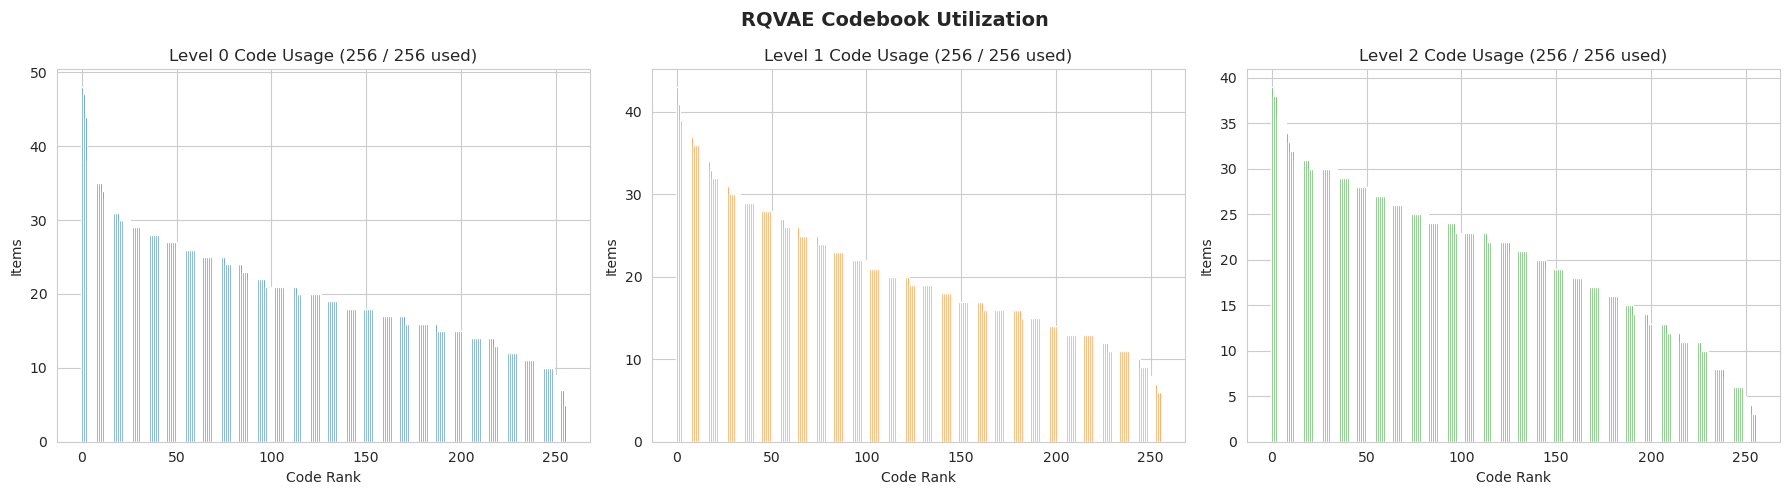


Collision distribution (3-level IDs):
  1 item(s)/ID:  5198 groups ( 5198 items,  99.4%)
  2 item(s)/ID:    17 groups (   34 items,   0.6%)


In [21]:
# Codebook usage and collision analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for level in range(3):
    counts = np.bincount(semantic_ids_3[:, level], minlength=256)
    axes[level].bar(range(256), sorted(counts, reverse=True), color=f'C{level}')
    axes[level].set_title(f'Level {level} Code Usage ({(counts > 0).sum()} / 256 used)')
    axes[level].set_xlabel('Code Rank')
    axes[level].set_ylabel('Items')
plt.suptitle('RQVAE Codebook Utilization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Collision distribution
collision_counts = Counter(Counter(tuples_3).values())
print(f'\nCollision distribution (3-level IDs):')
for size in sorted(collision_counts.keys()):
    n_groups = collision_counts[size]
    n_items = size * n_groups
    print(f'  {size} item(s)/ID: {n_groups:>5} groups ({n_items:>5} items, {100*n_items/len(semantic_ids_3):>5.1f}%)')

In [22]:
# ============================================================
# Checkpoint 2: Save semantic IDs and mappings (after cell above)
# ============================================================
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

with open(f'{CHECKPOINT_DIR}/data_checkpoint2.pkl', 'wb') as f:
    pickle.dump({
        'semantic_ids_3': semantic_ids_3,
        'semantic_ids_4': semantic_ids_4,
        'semantic_token_ids': semantic_token_ids,
        'app_id_to_tokens': app_id_to_tokens,
        'CODEBOOK_SIZE': CODEBOOK_SIZE,
        'NUM_LEVELS': NUM_LEVELS,
    }, f)
print(f'Checkpoint 2 saved: {len(app_id_to_tokens)} items with {NUM_LEVELS}-level Semantic IDs')

Checkpoint 2 saved: 5232 items with 4-level Semantic IDs


In [23]:
# ============================================================
# Load Checkpoint 2 (run this + checkpoint 1 load to skip RQVAE)
# ============================================================
CHECKPOINT_DIR = 'checkpoints'

with open(f'{CHECKPOINT_DIR}/data_checkpoint2.pkl', 'rb') as f:
    _ckpt = pickle.load(f)
    semantic_ids_3 = _ckpt['semantic_ids_3']
    semantic_ids_4 = _ckpt['semantic_ids_4']
    semantic_token_ids = _ckpt['semantic_token_ids']
    app_id_to_tokens = _ckpt['app_id_to_tokens']
    CODEBOOK_SIZE = _ckpt['CODEBOOK_SIZE']
    NUM_LEVELS = _ckpt['NUM_LEVELS']
    del _ckpt

print(f'Checkpoint 2 loaded: {len(app_id_to_tokens)} items, '
      f'{NUM_LEVELS} levels x {CODEBOOK_SIZE} codes')

Checkpoint 2 loaded: 5232 items, 4 levels x 256 codes
